In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    HybridPoolingV0(30,nn.AvgPool2d,nn.MaxPool2d),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60,nn.AvgPool2d,nn.MaxPool2d),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60,nn.AvgPool2d,nn.MaxPool2d),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60,nn.AvgPool2d,nn.MaxPool2d),          # 4 → 2

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model41_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model41_0)
describe(model41_0)

MACs: 5.36 MMac, Params: 37.23 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model41_0.pt
Starting
Epoch 1/60: Train loss = 1.0972, Train accuracy = 0.6085, Test loss = 1.0595, Test accuracy = 0.6225
Epoch 2/60: Train loss = 0.8757, Train accuracy = 0.6936, Test loss = 0.8253, Test accuracy = 0.7103
Epoch 3/60: Train loss = 0.8084, Train accuracy = 0.7211, Test loss = 0.8327, Test accuracy = 0.7186
Epoch 4/60: Train loss = 0.6726, Train accuracy = 0.7654, Test loss = 0.6780, Test accuracy = 0.7652
Epoch 5/60: Train loss = 0.6382, Train accuracy = 0.7772, Test loss = 0.6569, Test accuracy = 0.7753
Epoch 6/60: Train loss = 0.6064, Train accuracy = 0.7898, Test loss = 0.6202, Test accuracy = 0.7896
Epoch 7/60: Train loss = 0.5704, Train accuracy = 0.7998, Test loss = 0.5753, Test accuracy = 0.8048
Epoch 8/60: Train loss = 0.5612, Train accuracy = 0.8036, Test loss = 0.6047, Test accuracy = 0.7981
Epoch 9/60: Train loss = 0.5303, Train accuracy = 0.8136, Test loss = 0.5747, Test accuracy = 0.8027
Epoch 10/60: Train loss = 0.544

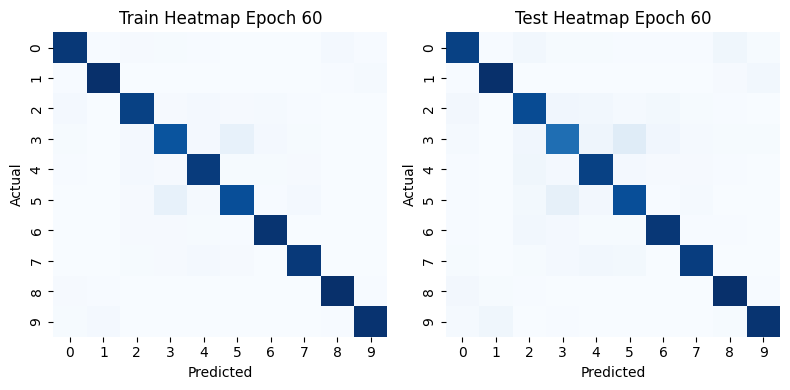

<Figure size 1200x600 with 0 Axes>

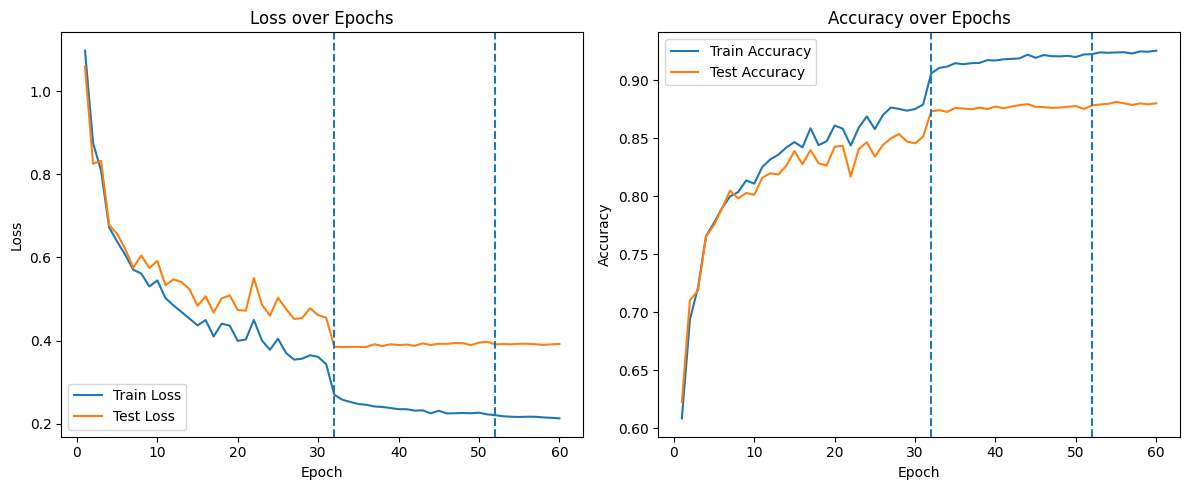

In [6]:
trainf32(model41_0,"model_weights/model41_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model41_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model41_1)
describe(model41_1)

MACs: 5.36 MMac, Params: 37.23 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model41_1.pt
Starting
Epoch 1/60: Train loss = 0.9605, Train accuracy = 0.6593, Test loss = 0.9214, Test accuracy = 0.6751
Epoch 2/60: Train loss = 0.8278, Train accuracy = 0.7120, Test loss = 0.8260, Test accuracy = 0.7137
Epoch 3/60: Train loss = 0.7437, Train accuracy = 0.7410, Test loss = 0.7593, Test accuracy = 0.7412
Epoch 4/60: Train loss = 0.6266, Train accuracy = 0.7848, Test loss = 0.6563, Test accuracy = 0.7750
Epoch 5/60: Train loss = 0.6244, Train accuracy = 0.7876, Test loss = 0.6511, Test accuracy = 0.7838
Epoch 6/60: Train loss = 0.5506, Train accuracy = 0.8092, Test loss = 0.5938, Test accuracy = 0.8003
Epoch 7/60: Train loss = 0.5458, Train accuracy = 0.8091, Test loss = 0.5679, Test accuracy = 0.8008
Epoch 8/60: Train loss = 0.5092, Train accuracy = 0.8236, Test loss = 0.5523, Test accuracy = 0.8096
Epoch 9/60: Train loss = 0.4863, Train accuracy = 0.8299, Test loss = 0.5433, Test accuracy = 0.8182
Epoch 10/60: Train loss = 0.471

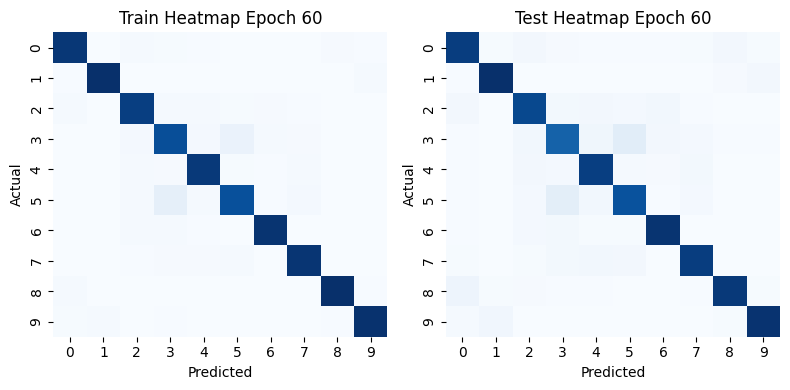

<Figure size 1200x600 with 0 Axes>

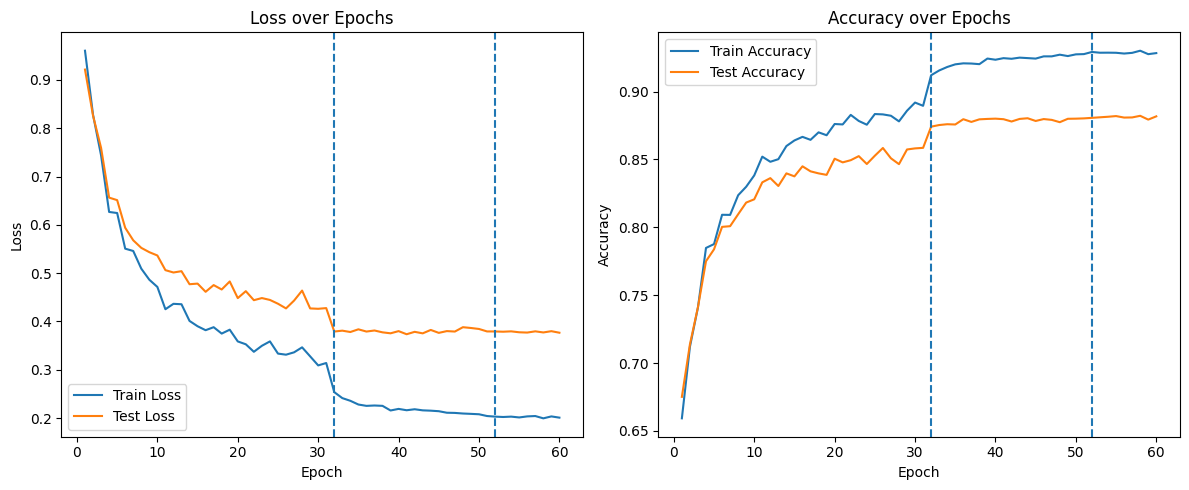

In [8]:
trainf32(model41_1,"model_weights/model41_1.pt",criterion,train_dataset,val_dataset, batch_size=64)